In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math
# For interactive visualization
import plotly.express as px
import plotly.graph_objects as go
import folium
from folium.plugins import HeatMap

/home/crimsondeepdarshak/Desktop/Deep_Darshak/code_/env/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


# AIS Data Visualization and Embedding Pipeline

This notebook loads interpolated AIS data and implements a fully modular embedding architecture. It includes fixes for CUDA indexing bugs and adds memory-efficient, interactive 2D and 3D visualisations.

In [2]:
# Load the dataset
df = pd.read_parquet("/home/crimsondeepdarshak/Desktop/Deep_Darshak/References/TRAIS_former_paper_Work_/CEE-Replication/Notebook/region_1_interpolated.parquet")
# We sample the dataset for interactive visualization purposes to avoid browser crash
df_sample = df.sample(min(50000, len(df)), random_state=42)
df.head()

,Time,MMSI,Longitude,Latitude,SOG,COG,IMO,Vessel type,Navstatus,is_interpolated
0,2025-01-01 00:01:44,103669999,-89.08701,30.364400,0.000000,313.100000,None,37,None,False
1,2025-01-01 00:11:44,103669999,-89.08719,30.364278,0.002151,313.034297,None,37,None,True
2,2025-01-01 00:21:44,103669999,-89.08737,30.364157,0.004301,312.968593,None,37,None,True
3,2025-01-01 00:31:44,103669999,-89.08755,30.364035,0.006452,312.902890,None,37,None,True
4,2025-01-01 00:41:44,103669999,-89.08773,30.363914,0.008602,312.837186,None,37,None,True


## 1. Interactive EDA (Exploratory Data Analysis)

Interactive 2D and 3D plotting helps us visually understand spatial distributions before discretization.

/tmp/ipykernel_13240/367217305.py:2: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


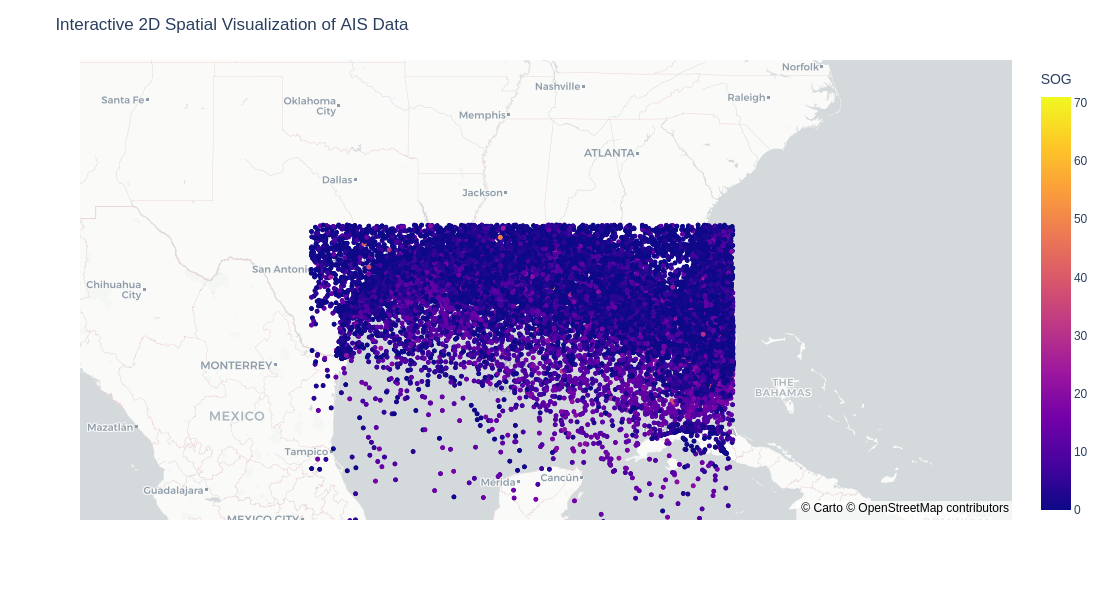

In [3]:
# 2D Interactive Scatter of Vessels
fig = px.scatter_mapbox(
    df_sample,
    lat="Latitude",
    lon="Longitude",
    color="SOG",
    hover_name="MMSI",
    hover_data=["Time", "COG", "SOG"],
    zoom=4,
    height=600,
)
fig.update_layout(mapbox_style="carto-positron", title="Interactive 2D Spatial Visualization of AIS Data")
fig.show()

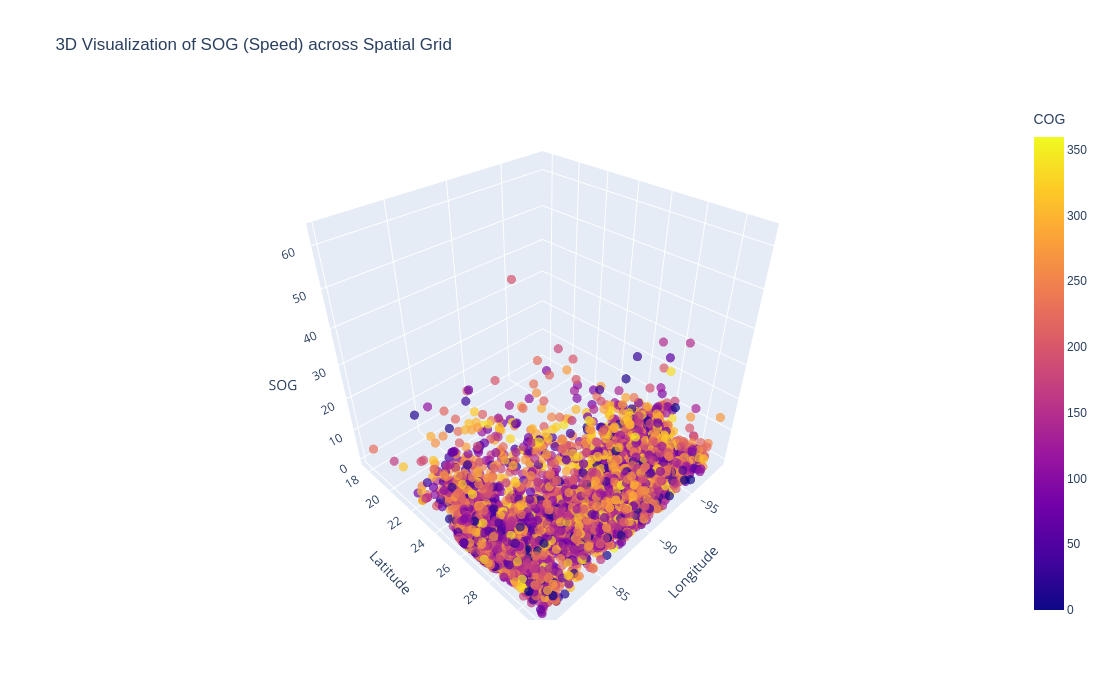

In [4]:
# 3D Interactive Visualization of SOG and COG
fig_3d = px.scatter_3d(
    df_sample.sample(min(10000, len(df_sample)), random_state=42), # smaller sample for 3D
    x="Longitude",
    y="Latitude",
    z="SOG",
    color="COG",
    opacity=0.7,
    title="3D Visualization of SOG (Speed) across Spatial Grid"
)
fig_3d.update_traces(marker=dict(size=3))
fig_3d.update_layout(height=700)
fig_3d.show()

## 2. Embedding Architecture

Here we define the modular components for embedding the AIS data. The features are discretized into bins, then encoded via embedding layers. Out of bounds values are tightly clamped to prevent `IndexError`.

In [5]:
class AISConfig:
    """
    Configuration class holding all hyperparameters for the AIS embedding pipeline.
    """
    def __init__(self, lat_range, lon_range, lat_res=0.01, lon_res=0.01, sog_res=1.0, cog_res=5.0, max_sog=40, embed_dim=64, device="cuda"):
        self.lat_min, self.lat_max = lat_range
        self.lon_min, self.lon_max = lon_range
        self.lat_res, self.lon_res = lat_res, lon_res
        self.sog_res, self.cog_res = sog_res, cog_res
        self.max_sog = max_sog
        self.embed_dim = embed_dim
        self.device = torch.device(device if torch.cuda.is_available() else "cpu")

        # Bin counts, conservatively rounded up
        self.N_lat = int(math.ceil((self.lat_max - self.lat_min) / lat_res)) + 1
        self.N_lon = int(math.ceil((self.lon_max - self.lon_min) / lon_res)) + 1
        self.N_sog = int(math.ceil(max_sog / sog_res)) + 1
        self.N_cog = int(math.ceil(360 / cog_res)) + 1

    def summary(self):
        print("===== AIS CONFIG =====")
        print(f"Lat bins: {self.N_lat}, Lon bins: {self.N_lon}")
        print(f"SOG bins: {self.N_sog}, COG bins: {self.N_cog}")
        print(f"Total embedding dim: {self.embed_dim * 4}")

In [6]:
class AISDiscretizer:
    """
    Converts raw continuous AIS features into discrete indices.
    Values are tightly clamped to avoid out-of-bounds indices which cause CUDA kernel crashes.
    """
    def __init__(self, config):
        self.cfg = config

    def forward(self, tensor):
        lat, lon, sog, cog = tensor.T
        lat_bin = torch.clamp(torch.floor((lat - self.cfg.lat_min) / self.cfg.lat_res).long(), 0, self.cfg.N_lat - 1)
        lon_bin = torch.clamp(torch.floor((lon - self.cfg.lon_min) / self.cfg.lon_res).long(), 0, self.cfg.N_lon - 1)
        sog_bin = torch.clamp(torch.floor(sog / self.cfg.sog_res).long(), 0, self.cfg.N_sog - 1)
        cog_bin = torch.clamp(torch.floor(cog / self.cfg.cog_res).long(), 0, self.cfg.N_cog - 1)
        return lat_bin, lon_bin, sog_bin, cog_bin

In [7]:
class AISFourHotEncoder:
    """
    Converts discrete indices to a 4-hot sparse representation.
    """
    def __init__(self, config):
        self.cfg = config

    def forward(self, lat_bin, lon_bin, sog_bin, cog_bin):
        N = len(lat_bin)
        lat_onehot = torch.zeros((N, self.cfg.N_lat), device=self.cfg.device)
        lon_onehot = torch.zeros((N, self.cfg.N_lon), device=self.cfg.device)
        sog_onehot = torch.zeros((N, self.cfg.N_sog), device=self.cfg.device)
        cog_onehot = torch.zeros((N, self.cfg.N_cog), device=self.cfg.device)
        
        lat_onehot[torch.arange(N), lat_bin] = 1
        lon_onehot[torch.arange(N), lon_bin] = 1
        sog_onehot[torch.arange(N), sog_bin] = 1
        cog_onehot[torch.arange(N), cog_bin] = 1
        
        return torch.cat([lat_onehot, lon_onehot, sog_onehot, cog_onehot], dim=1)

In [8]:
import torch.nn as nn

class AISEmbeddingBuilder(nn.Module):
    """
    Embedding lookup layer that compiles feature indices into dense vector representations.
    """
    def __init__(self, config):
        super().__init__()
        self.cfg = config
        self.lat_embed = nn.Embedding(config.N_lat, config.embed_dim)
        self.lon_embed = nn.Embedding(config.N_lon, config.embed_dim)
        self.sog_embed = nn.Embedding(config.N_sog, config.embed_dim)
        self.cog_embed = nn.Embedding(config.N_cog, config.embed_dim)

    def forward(self, lat_bin, lon_bin, sog_bin, cog_bin):
        e_lat = self.lat_embed(lat_bin)
        e_lon = self.lon_embed(lon_bin)
        e_sog = self.sog_embed(sog_bin)
        e_cog = self.cog_embed(cog_bin)
        return torch.cat([e_lat, e_lon, e_sog, e_cog], dim=-1)

In [9]:
class AISReconstructor:
    """
    Reconstructs continuous features from discrete bins for error estimation.
    Uses bin midpoints.
    """
    def __init__(self, config):
        self.cfg = config

    def reconstruct(self, lat_bin, lon_bin, sog_bin, cog_bin):
        lat = self.cfg.lat_min + (lat_bin + 0.5) * self.cfg.lat_res
        lon = self.cfg.lon_min + (lon_bin + 0.5) * self.cfg.lon_res
        sog = (sog_bin + 0.5) * self.cfg.sog_res
        cog = (cog_bin + 0.5) * self.cfg.cog_res
        return torch.stack([lat, lon, sog, cog], dim=1)

In [10]:
class AISVisualizer:
    """
    Utility class for visualizing distributions, spatial grid occupancy, and reconstruction bounds.
    """
    @staticmethod
    def spatial_grid_plot(lat_bin, lon_bin):
        plt.figure(figsize=(10, 8))
        # Use a 2D histogram for better heatmap representation instead of scatter for large data
        plt.hist2d(lon_bin.cpu().numpy(), lat_bin.cpu().numpy(), bins=100, cmap='viridis')
        plt.colorbar(label='Density')
        plt.title("Spatial Grid Occupancy Heatmap")
        plt.xlabel("Longitude Bin")
        plt.ylabel("Latitude Bin")
        plt.show()

    @staticmethod
    def bin_histogram(bin_tensor, title):
        plt.figure(figsize=(8, 5))
        sns.histplot(bin_tensor.cpu().numpy(), bins=50, kde=False, color='blue', alpha=0.6)
        plt.title(title)
        plt.xlabel("Bin Index")
        plt.ylabel("Frequency")
        plt.show()

    @staticmethod
    def reconstruction_error(original, reconstructed):
        error = torch.norm(original - reconstructed, dim=1)
        plt.figure(figsize=(8, 5))
        sns.histplot(error.cpu().numpy(), bins=50, kde=True, color='red', alpha=0.6)
        plt.title("Reconstruction Error Distribution")
        plt.xlabel("L2 Error")
        plt.ylabel("Frequency")
        plt.show()
        print(f"Mean reconstruction error: {error.mean().item():.4f}")

## 3. Example Usage & Testing the Pipeline

Run the embedding builder on a large sample to prevent OutOfMemory issues, but enough to see the patterns.

In [11]:
# Set configuration
config = AISConfig(
    lat_range=(df.Latitude.min(), df.Latitude.max()),
    lon_range=(df.Longitude.min(), df.Longitude.max()),
    lat_res=0.01,
    lon_res=0.01,
    sog_res=1.0,
    cog_res=5.0,
    embed_dim=64
)
config.summary()

# Move a sample of data to GPU/CPU for processing
# Using full data (28M rows) causes CUDA OutOfMemory on small GPUs, so we process on a reasonably large sample.
sample_size = min(1000000, len(df))
tensor = torch.tensor(
    df[["Latitude", "Longitude", "SOG", "COG"]].sample(sample_size, random_state=42).values,
    dtype=torch.float32,
    device=config.device
)

===== AIS CONFIG =====
Lat bins: 1367, Lon bins: 1855
SOG bins: 41, COG bins: 73
Total embedding dim: 256


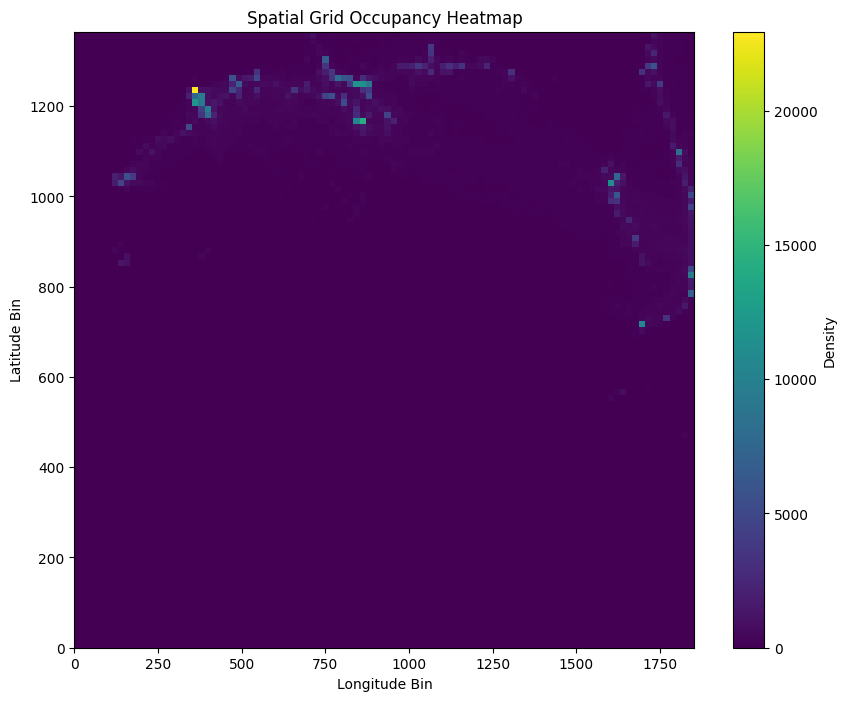

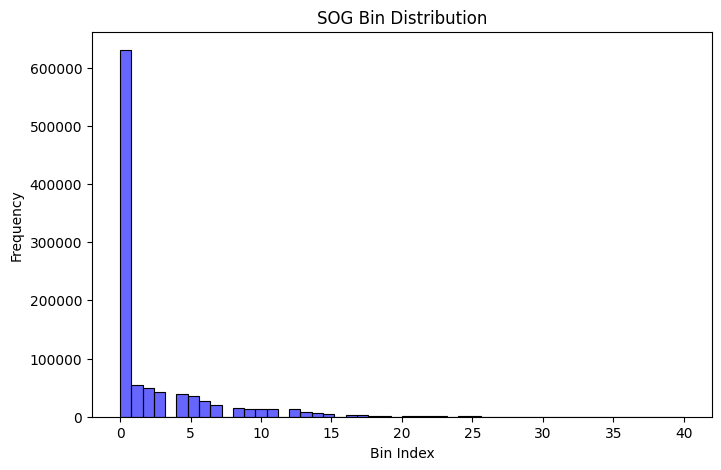

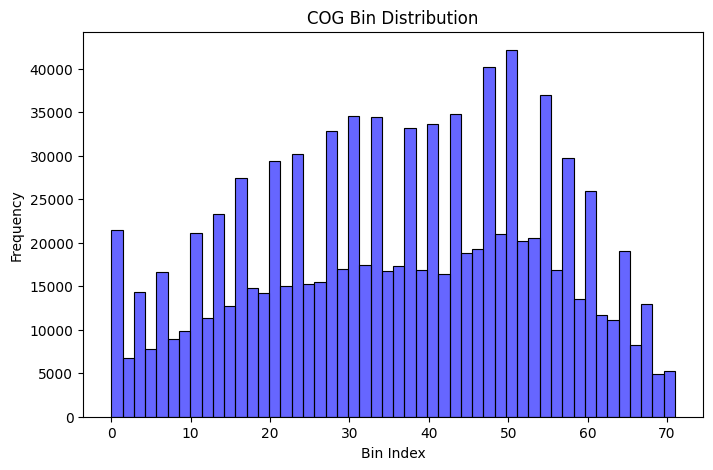

In [12]:
# Discretization
discretizer = AISDiscretizer(config)
lat_bin, lon_bin, sog_bin, cog_bin = discretizer.forward(tensor)

# Visualization
visualizer = AISVisualizer()
visualizer.spatial_grid_plot(lat_bin, lon_bin)
visualizer.bin_histogram(sog_bin, "SOG Bin Distribution")
visualizer.bin_histogram(cog_bin, "COG Bin Distribution")

In [13]:
# Building Embeddings
embedding_builder = AISEmbeddingBuilder(config).to(config.device)
# Ensure we do not run out of memory when gathering embeddings
subset_idx = slice(0, 100000)
embeddings = embedding_builder(lat_bin[subset_idx], lon_bin[subset_idx], sog_bin[subset_idx], cog_bin[subset_idx])
print(f"Embedding tensor shape for subset: {embeddings.shape}")

Embedding tensor shape for subset: torch.Size([100000, 256])


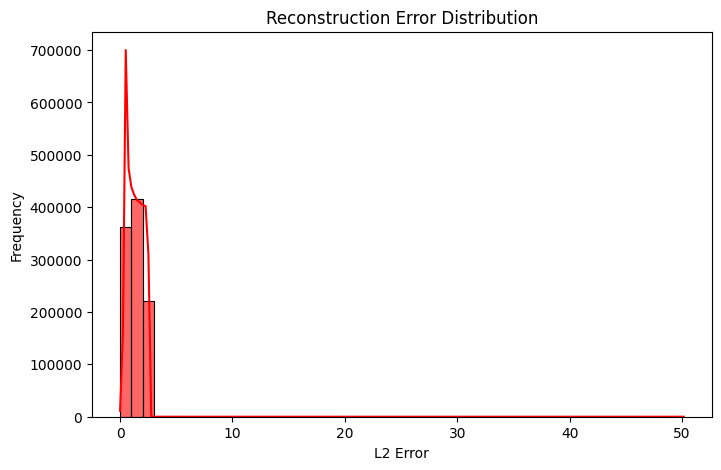

Mean reconstruction error: 1.3599


In [14]:
# Errors and Reconstruction
reconstructor = AISReconstructor(config)
reconstructed = reconstructor.reconstruct(lat_bin, lon_bin, sog_bin, cog_bin)
visualizer.reconstruction_error(tensor, reconstructed)

## 4. Hyperparameter Effects on Reconstruction

Let's see what happens if we change the resolution (e.g. create larger spatial/temporal bins). A coarser grid will generally result in higher reconstruction error and lower variance.

===== AIS CONFIG =====
Lat bins: 138, Lon bins: 187
SOG bins: 9, COG bins: 25
Total embedding dim: 256


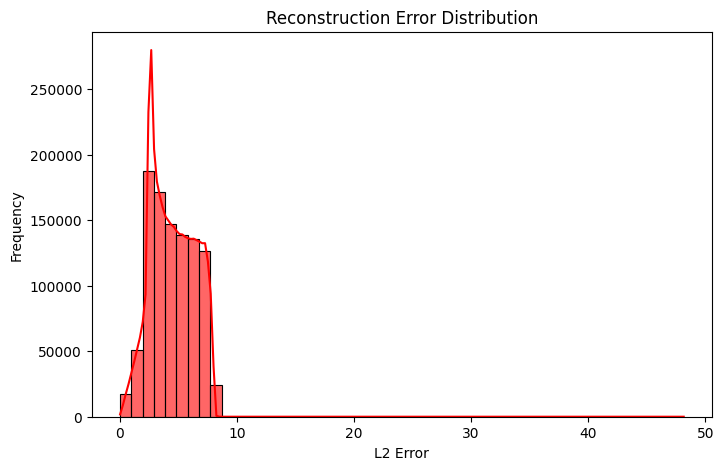

Mean reconstruction error: 4.4771


In [15]:
# Coarser Grain Resolution
config_coarse = AISConfig(
    lat_range=(df.Latitude.min(), df.Latitude.max()),
    lon_range=(df.Longitude.min(), df.Longitude.max()),
    lat_res=0.1, # 10x larger spatial bins
    lon_res=0.1,
    sog_res=5.0, # 5x larger speed bins
    cog_res=15.0,
    embed_dim=64
)
config_coarse.summary()

discretizer_coarse = AISDiscretizer(config_coarse)
lat_bin_c, lon_bin_c, sog_bin_c, cog_bin_c = discretizer_coarse.forward(tensor)

reconstructor_coarse = AISReconstructor(config_coarse)
reconstructed_coarse = reconstructor_coarse.reconstruct(lat_bin_c, lon_bin_c, sog_bin_c, cog_bin_c)
visualizer.reconstruction_error(tensor, reconstructed_coarse)

### Important Insight for Your Maritime Research

**Smaller bins:**
- Better lane resolution
- Higher memory usage
- Higher sparsity
- Lower bias, higher variance

**Larger bins:**
- Smoother lanes
- Better generalization
- Lower variance
- High bias, low variance

This becomes a maritime bias-variance tradeoff that needs optimizing based on your specific downstream task in the CEE-Replication pipeline.